In [68]:
import torch
import torchvision
import torchvision.transforms as transforms
from  torch.utils.data import Subset
import sklearn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import MiniBatchDictionaryLearning
from sklearn.datasets import make_sparse_coded_signal

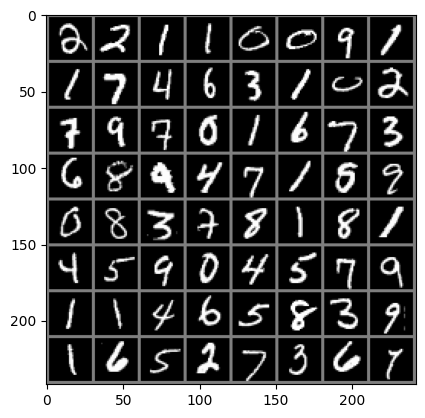

    2     2     1     1     0     0     9     1


In [333]:
# Define a transform to normalize the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

TRAIN = 60000
TEST = 10000
# Download and load the training data
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=False, transform=transform)

# take smaller chunk of the data for training
sub_train = Subset(trainset, range(TRAIN))
raw_trainloader = torch.utils.data.DataLoader(sub_train, batch_size=64, shuffle=True)

# Download and load the test data
testset = torchvision.datasets.MNIST(root='./data', train=False, download=False, transform=transform)
sub_test = Subset(testset, range(TEST))
testloader = torch.utils.data.DataLoader(sub_test, batch_size=10, shuffle=False)

# Function to show an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random training images
dataiter = next(iter(raw_trainloader))
images, labels = dataiter

# Show images
imshow(torchvision.utils.make_grid(images))
# Print labels
print(' '.join('%5s' % labels[j].item() for j in range(8)))

In [375]:
d = trainset.data[0]
print(torch.max(d), torch.min(d))

tensor(255, dtype=torch.uint8) tensor(0, dtype=torch.uint8)


In [428]:
N_COMP = 250

def encode(data):
    dict_learner = MiniBatchDictionaryLearning(n_components=N_COMP, split_sign=True, batch_size=64, max_iter=20, random_state=42)
    data_flat = data.view(len(data), -1).numpy()
    learned_dict = dict_learner.fit(data_flat)
    sparse_codes = learned_dict.transform(data_flat)
    
    return sparse_codes, learned_dict


class Sparse(torch.utils.data.Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
        
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sparse_code, target = self.data[idx], self.labels[idx]
        
        return sparse_code, target

train_data,train_labels = trainset.data[:TRAIN], trainset.targets[:TRAIN]
test_data,test_labels = testset.data[:TEST], testset.targets[:TEST]

full_data = torch.cat((train_data, test_data), axis=0)
data,learned_dict = encode(full_data)

SPARSE_SIZE = data.shape[1]

train_data = data[:TRAIN]
test_data = data[TRAIN:]
# Create the custom dataset and dataloader
sparse_trainset = Sparse(train_data, train_labels)
sparse_trainloader = torch.utils.data.DataLoader(sparse_trainset, batch_size=64, shuffle=True)

sparse_testset = Sparse(test_data, test_labels)
sparse_testloader = torch.utils.data.DataLoader(sparse_testset, batch_size=64, shuffle=True)

In [429]:
SPARSE_SIZE

500

In [430]:
class Net(torch.nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(Net, self).__init__()
        self.fc1 = torch.nn.Linear(input_size, hidden_size)
        self.relu = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(hidden_size, hidden_size)
        self.fc3 = torch.nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        out = self.relu(self.fc1(x))
        out = self.relu(self.fc2(out))
        out = self.fc3(out)
        return out

In [431]:
EPOCHS = 50
LR = 1e-4
HIDDEN_SIZE = 128
INPUT_SIZE = 784
NUM_CLASSES = 10
torch.manual_seed(42)
raw_model = Net(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES)
sparse_model = Net(input_size=SPARSE_SIZE, hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES)

opt1 = torch.optim.Adam(raw_model.parameters(), lr=LR)
opt2 = torch.optim.Adam(sparse_model.parameters(), lr=LR)

criterion = torch.nn.CrossEntropyLoss()

In [432]:
def train(model, optimizer, criterion, trainloader, epochs, sparse=False):
    losses = []
    for epoch in range(epochs):
        correct = 0
        total = 0
        for i, data in enumerate(trainloader):
            images, labels = data
            if sparse:
                images = images.view(-1, SPARSE_SIZE)
            else:
                images = images.view(-1, INPUT_SIZE)
            images = images.float()
            outputs = model(images)
            loss = criterion(outputs, labels)

            outputs = torch.nn.functional.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if epoch % 10 == 0 and i == 0:
                print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, epochs, loss.item()))
            losses.append(loss.item())
        if epoch % 10 == 0:
            print("accuracy: ", correct/total)
            
    return losses

print('Training Raw')
raw_losses = train(raw_model, opt1, criterion, raw_trainloader, EPOCHS)
print("="*10)
print('Training Sparse')
sparse_losses = train(sparse_model, opt2, criterion, sparse_trainloader, EPOCHS, sparse=True)


Training Raw
Epoch [1/50], Loss: 2.3002
accuracy:  0.8174333333333333
Epoch [11/50], Loss: 0.1380
accuracy:  0.9664833333333334
Epoch [21/50], Loss: 0.0994
accuracy:  0.9822666666666666
Epoch [31/50], Loss: 0.0044
accuracy:  0.9904
Epoch [41/50], Loss: 0.0393
accuracy:  0.9947
Training Sparse
Epoch [1/50], Loss: 15.6388
accuracy:  0.6085166666666667
Epoch [11/50], Loss: 0.0042
accuracy:  0.9990833333333333
Epoch [21/50], Loss: 0.0001
accuracy:  1.0
Epoch [31/50], Loss: 0.0000
accuracy:  0.99685
Epoch [41/50], Loss: 0.0000
accuracy:  1.0


In [433]:
def test(model, testloader, sparse = False):
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            if sparse:
                images = images.view(-1, SPARSE_SIZE)
            else:
                images = images.view(-1, INPUT_SIZE)
            images = images.float()
            outputs = model(images)
            outputs = torch.nn.functional.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

print(f"Raw Test Acc: {test(raw_model, testloader)}")
print(f"Sparse Test Acc: {test(sparse_model, sparse_testloader, sparse=True)}")

Raw Test Acc: 0.9768
Sparse Test Acc: 0.9481


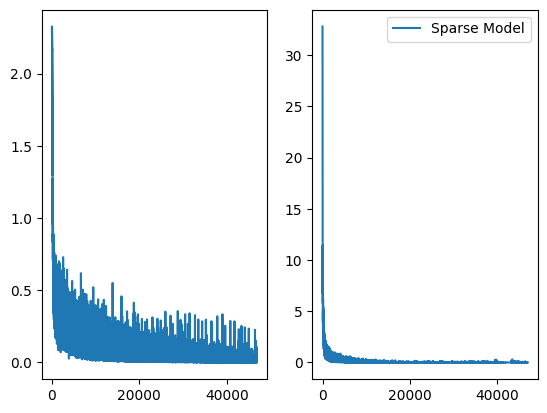

In [424]:
fig,(ax1,ax2) = plt.subplots(1,2)

ax1.plot(raw_losses, label='Raw Model')
ax2.plot(sparse_losses, label='Sparse Model')
plt.legend()
plt.show()


In [426]:
def count_zero_weights(model):
    zero_count = 0
    for param in model.parameters():
        #print(param)
        zero_count += torch.sum(torch.sum(param*param))
    return zero_count

# Count the number of zero weights in the model
raw_n_zeros = count_zero_weights(raw_model)
sparse_n_zeros = count_zero_weights(sparse_model)

print(f"Raw Model params L2: {raw_n_zeros}")
print(f"Sparse Model params L2: {sparse_n_zeros}")

Raw Model params L2: 363.71478271484375
Sparse Model params L2: 112.9341049194336


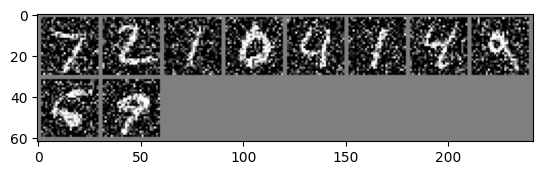

Raw Predictions:  tensor(8)
Sparse Predictions:  tensor(6)
Raw Predictions:  tensor([7, 2, 1, 0, 9, 7, 4, 9, 5, 9])
Sparse Predictions:  tensor([7, 2, 7, 0, 4, 1, 5, 9, 6, 7])
Labels:  tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


In [427]:
torch.random.manual_seed(42)
images,labels = next(iter(testloader))
noise = torch.randn_like(images)*0.8
noisy_images = images + noise
noisy_images = torch.clamp(noisy_images, -1, 1)
imshow(torchvision.utils.make_grid(noisy_images))
with torch.no_grad():
    raw_model.eval()
    sparse_model.eval()

    raw_outputs = raw_model(noisy_images.view(-1, 784).float())
    clipped = torch.clamp(noisy_images, 0, 1)
    clipped *= 255
    sprs = learned_dict.transform(clipped.view(len(noisy_images), -1).numpy())
    sprs = torch.tensor(sprs)
    sparse_outputs = sparse_model(sprs.float())
    
    raw_outputs = torch.nn.functional.softmax(raw_outputs, dim=1)
    sparse_outputs = torch.nn.functional.softmax(sparse_outputs, dim=1)
    _, raw_predicted = torch.max(raw_outputs.data, 1)
    _, sparse_predicted = torch.max(sparse_outputs.data, 1)
    
    print("Raw Predictions: ", torch.sum(raw_predicted==labels))
    print("Sparse Predictions: ", torch.sum(sparse_predicted==labels))
    print("Raw Predictions: ", raw_predicted)
    print("Sparse Predictions: ", sparse_predicted)
    print("Labels: ", labels)